In [2]:
library(ggplot2)
library(readr)
library(corrplot)
library(FactoMineR)

Warning message:
"package 'ggplot2' was built under R version 4.5.3"
Warning message:
"package 'readr' was built under R version 4.5.3"
Warning message:
"package 'corrplot' was built under R version 4.5.3"
corrplot 0.95 loaded

Warning message:
"package 'FactoMineR' was built under R version 4.5.3"


In [3]:
europe <- read_table("C:\\Users\\Julien ANTOGNELLI\\Documents\\ESGI\\Maths\\MathsForR\\data\\Donnees Europe.dat", 
    skip = 1,
    col_names =c (
        "pays", "benev", "chom", "depsoc", "devel", "heur", "pib",
        "satfam", "satlogt", "satnvie", "spauvr", "ssabri", "vief", "vieh")
)


── Column specification ────────────────────────────────────────────────────────
cols(
  pays = col_character(),
  benev = col_double(),
  chom = col_double(),
  depsoc = col_double(),
  devel = col_double(),
  heur = col_double(),
  pib = col_double(),
  satfam = col_double(),
  satlogt = col_double(),
  satnvie = col_double(),
  spauvr = col_double(),
  ssabri = col_double(),
  vief = col_double(),
  vieh = col_double()
)



# Introduction au jeu de données

In [4]:
head(europe)

pays,benev,chom,depsoc,devel,heur,pib,satfam,satlogt,satnvie,spauvr,ssabri,vief,vieh
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
at,60,4.7,29.1,0.944,20,128.8,8.2,39,32,900,3,82,77
be,37,8.1,29.3,0.945,40,112.3,7.9,55,35,822,5,82,77
cy,23,4.6,17.8,0.903,24,93.2,7.9,49,24,658,4,82,77
cz,33,7.7,19.6,0.885,16,79.4,7.5,37,14,212,6,79,73
de,52,9.1,29.5,0.932,24,113.6,8.1,52,31,856,2,82,76
dk,49,4.9,30.7,0.943,49,126.7,8.7,55,55,1106,1,80,76


## Graphes de couples de variables

### Couple `chom`et `depsoc`

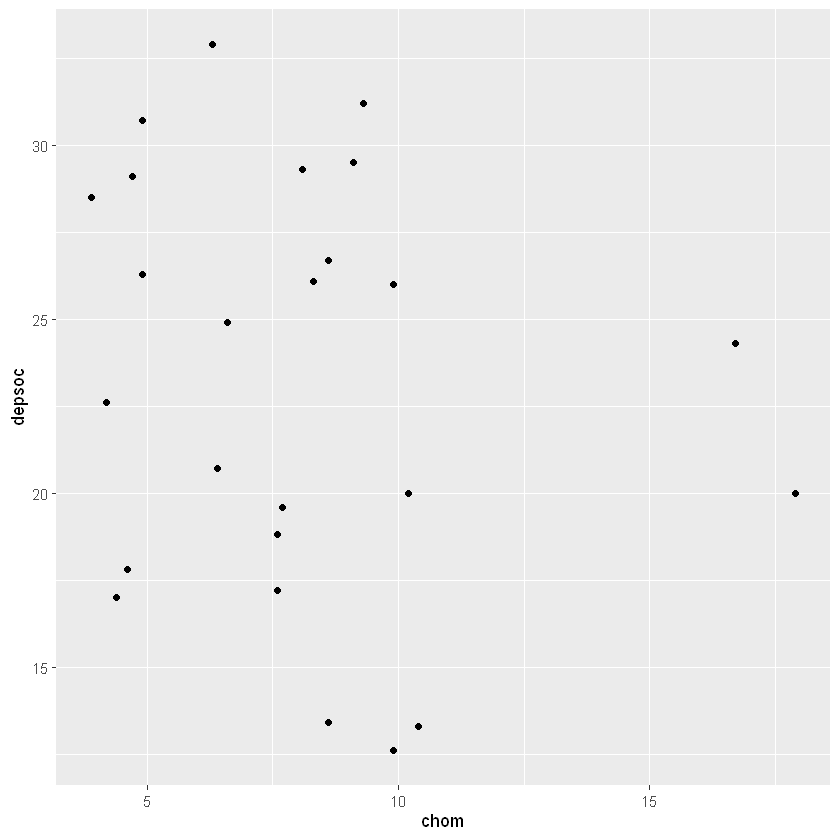

In [5]:
ggplot(europe, aes(x = chom, y = depsoc)) +
  geom_point() +
  labs(x = "chom",
       y = "depsoc")


### Couple `PIB`et `devel`

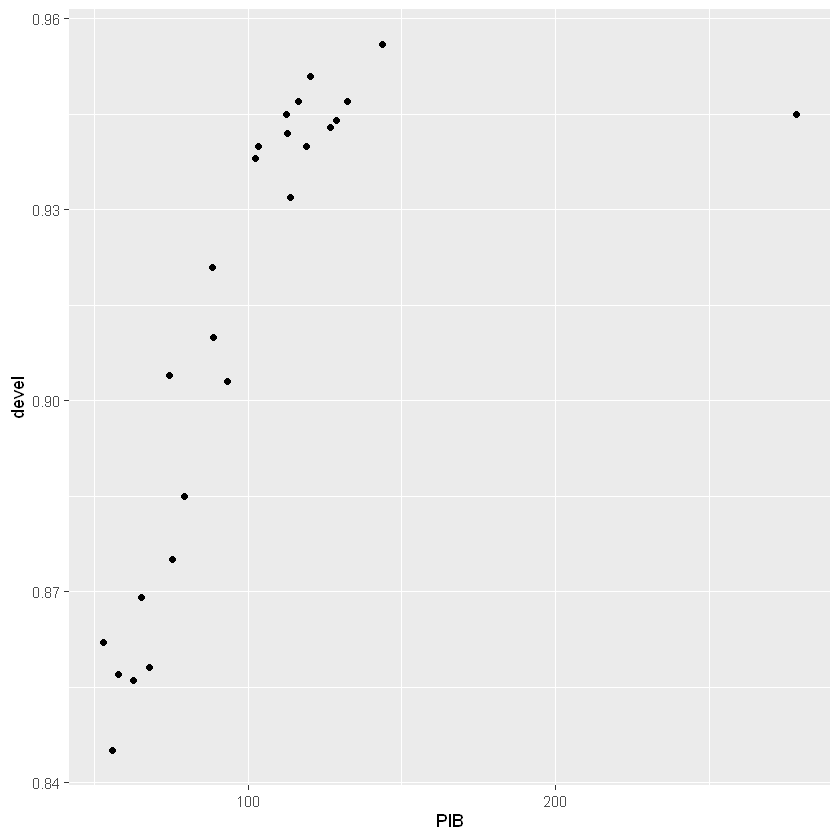

In [6]:
ggplot(europe, aes(x = pib, y = devel)) +
  geom_point() +
  labs(x = "PIB",
       y = "devel")

### Couple `benev`et `pvapr`
**TODO** /!\ `pvapr`n'existe pas dans le fichier

## Matrice des corrélations des variables

In [7]:
Europe_num <- europe[, -1]   # enlève la colonne pays

In [8]:
cor_mat <- round(cor(Europe_num, method = "pearson"), 2)
cor_mat
write.csv(cor_mat, file = "./graphs_&_tables/corr_matrix.csv", row.names = TRUE)

,benev,chom,depsoc,devel,heur,pib,satfam,satlogt,satnvie,spauvr,ssabri,vief,vieh
benev,1.00,-0.41,0.58,0.62,0.52,0.56,0.39,0.52,0.58,0.67,-0.56,0.40,0.43
chom,-0.41,1.00,-0.19,-0.56,-0.57,-0.55,-0.40,-0.54,-0.61,-0.63,0.40,-0.35,-0.46
depsoc,0.58,-0.19,1.00,0.70,0.49,0.36,0.47,0.39,0.49,0.61,-0.50,0.59,0.66
devel,0.62,-0.56,0.70,1.00,0.76,0.69,0.67,0.61,0.74,0.88,-0.55,0.86,0.84
heur,0.52,-0.57,0.49,0.76,1.00,0.64,0.61,0.80,0.88,0.81,-0.52,0.51,0.63
pib,0.56,-0.55,0.36,0.69,0.64,1.00,0.54,0.70,0.80,0.87,-0.48,0.52,0.52
satfam,0.39,-0.40,0.47,0.67,0.61,0.54,1.00,0.68,0.77,0.72,-0.64,0.60,0.77
satlogt,0.52,-0.54,0.39,0.61,0.80,0.70,0.68,1.00,0.83,0.79,-0.59,0.49,0.65
satnvie,0.58,-0.61,0.49,0.74,0.88,0.80,0.77,0.83,1.00,0.89,-0.63,0.52,0.68
spauvr,0.67,-0.63,0.61,0.88,0.81,0.87,0.72,0.79,0.89,1.00,-0.54,0.70,0.76


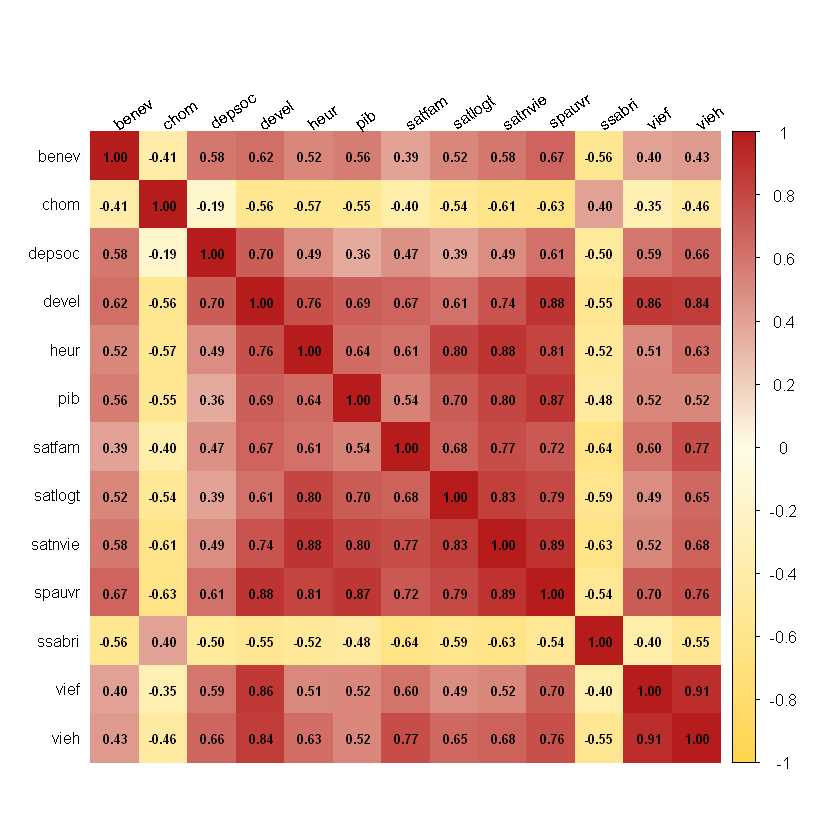

In [9]:
corrplot(cor_mat,
         method = "color",
         type = "full",
         diag = TRUE,
         col = colorRampPalette(c("#FFD54F", "#FFFDE7", "#B71C1C"))(200),
         tl.col = "black",
         tl.cex = 0.8,
         tl.srt = 35,
         addCoef.col = "black",
         number.cex = 0.65,
         mar = c(1, 1, 2, 1)
         )

**Interprétation**

Le couple de variables le plus corrélé est (vief, vieh) avec un coefficient de corrélation de 0,91, ce qui traduit une très forte liaison linéaire positive.

Le couple le moins corrélé est (chom, depsoc) avec -0,19, la liaison linéaire étant très faible.

Le couple de variables le plus opposé est (satfam, ssabri) avec -0,64, ce qui indique une corrélation négative marquée.

**TODO** -- Pour chacun des couples (chom, depsoc), (pib, devel) et (benev, pvap), commentez la répartition
des valeurs, identi ez les éventuels individus "anormaux" et expliquez le lien avec les corrélations
mesurées.

# Première ACP

### Pré-traitement du df avant manipulations

In [10]:
europe <- as.data.frame(europe)

# Mettre la 1re colonne (pays) en noms de lignes
rownames(europe) <- europe[, 1]

# Supprimer la 1re colonne du tableau de données
europe_num <- europe[, -1]

## Centrer et réduire les données

In [11]:
res.pca <- PCA(europe_num, scale.unit = TRUE, ncp = 4, graph = FALSE)

## Variances des composantes principales

In [12]:
variances_cp <- data.frame(
  Axe = paste0("Dim.", 1:4),
  Variance = round(res.pca$eig[1:4, 1], 4)
)

variances_cp
write.csv(variances_cp, file = "./graphs_&_tables/variances_cp.csv", row.names = FALSE)

,Axe,Variance
,<chr>,<dbl>
comp 1,Dim.1,8.3909
comp 2,Dim.2,1.2172
comp 3,Dim.3,0.8408
comp 4,Dim.4,0.7304


## Tableau de corrélation des variables

In [13]:
corr_variables <- round(res.pca$var$cor[, 1:4], 4)
corr_variables
write.csv(corr_variables, file = "./graphs_&_tables/corr_variables.csv", row.names = TRUE)

,Dim.1,Dim.2,Dim.3,Dim.4
benev,0.6880,-0.0388,-0.5956,0.2495
chom,-0.6360,0.4325,-0.1705,-0.2454
depsoc,0.6691,0.5168,-0.3532,0.0764
devel,0.9143,0.2305,0.0658,0.2109
heur,0.8467,-0.2222,0.0541,-0.0001
pib,0.8001,-0.3045,0.0237,0.2058
satfam,0.8005,0.0800,0.1641,-0.4432
satlogt,0.8304,-0.3014,0.0592,-0.1975
satnvie,0.9122,-0.2695,0.0167,-0.1137
spauvr,0.9556,-0.0845,0.0379,0.1693


## Coordonées des individus sur les axes

In [14]:
coord_individus <- round(res.pca$ind$coord[, 1:4], 4)
coord_individus
write.csv(coord_individus, file = "./graphs_&_tables/coord_individus.csv", row.names = TRUE)

,Dim.1,Dim.2,Dim.3,Dim.4
at,2.2026,0.5746,-1.1379,0.7055
be,2.0526,0.4308,-0.0443,0.1003
cy,0.2642,-0.3718,1.2112,-0.4768
cz,-1.9987,-0.3383,-0.4339,-0.1758
de,1.8218,0.7689,-1.1992,-0.2011
dk,3.8231,-0.9105,-0.8755,-0.7656
ee,-4.1636,-1.1473,-0.7150,0.8575
es,0.3029,1.2867,1.5153,-0.6805
fi,1.7138,0.7827,-0.8622,-0.0062
fr,0.5918,1.8470,0.5494,2.0517


## Contribution des individus aux axes 

In [15]:
contrib_individus <- round(res.pca$ind$contrib[, 1:4], 2)
contrib_individus
write.csv(contrib_individus, file = "./graphs_&_tables/contrib_individus.csv", row.names = TRUE)

,Dim.1,Dim.2,Dim.3,Dim.4
at,2.31,1.08,6.16,2.73
be,2.01,0.61,0.01,0.06
cy,0.03,0.45,6.98,1.24
cz,1.90,0.38,0.90,0.17
de,1.58,1.94,6.84,0.22
dk,6.97,2.72,3.65,3.21
ee,8.26,4.33,2.43,4.03
es,0.04,5.44,10.92,2.54
fi,1.40,2.01,3.54,0.00
fr,0.17,11.21,1.44,23.05


## Faire une représentation graphique des valeurs propres

In [20]:
png("./graphs_&_tables/valeurs_propres.png", width = 800, height = 600, res = 120)

vp <- res.pca$eig[, 1]

plot(1:length(vp), vp, type = "b", pch = 19,
     xlab = "Axes principaux",
     ylab = "Valeurs propres")

abline(h = 1, col = "red", lty = 2)

legend("topright",
       legend = expression("Critère de Kaiser (" * lambda == 1 * ")"),
       col = "red",
       lty = 2,
       lwd = 1,
       bty = "n")

dev.off()

pdf 
  2

Selon la règle de Kaiser (valeur propre > 1, ligne rouge) :

2 composantes principales sont à retenir: l'axe 1 (~8.5) et l'axe 2 (~1.2) sont au-dessus du seuil, l'axe 3 passe déjà en dessous.

## Pourcentage d'inertie totale expliquée par le sous-espace principal correspondant

In [17]:
# Garder seulement celles avec valeur propre > 1
res.pca$eig[res.pca$eig[, 1] > 1, ]

,eigenvalue,percentage of variance,cumulative percentage of variance
comp 1,8.390877,64.545210,64.54521
comp 2,1.217164,9.362799,73.90801


Le sous-espace principal des 2 premières composantes explique 73.91% de l'inertie totale.

## Tracer le cercle de corrélation des variables

pdf 
  2

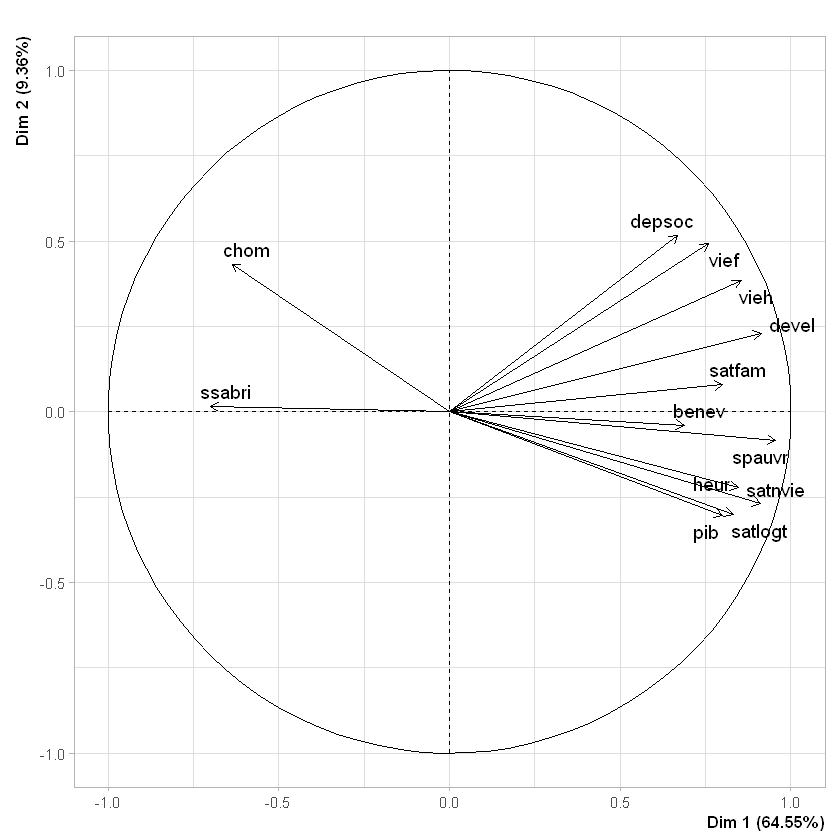

In [23]:
png("./graphs_&_tables/cercle_correlation.png", width = 800, height = 800, res = 120)

plot(res.pca, choix = "var", axes = c(1, 2), title = " ")

dev.off()

# Affichage
plot(res.pca, choix = "var", axes = c(1, 2), title="")

In [26]:
corr_vars <- round(res.pca$var$coord[, 1:2], 4)

axe_dominant <- apply(corr_vars, 1, function(x) {
  if (abs(x[1]) > abs(x[2])) {
    paste0("Dim 1 (", ifelse(x[1] >= 0, "+", "-"), ")")
  } else if (abs(x[2]) > abs(x[1])) {
    paste0("Dim 2 (", ifelse(x[2] >= 0, "+", "-"), ")")
  } else {
    "Dim 1 et 2"
  }
})

tab_axes <- data.frame(
  Variable = rownames(corr_vars),
  `Axe dominant` = axe_dominant,
  `r (Dim 1)` = corr_vars[, 1],
  `r (Dim 2)` = corr_vars[, 2],
  row.names = NULL,
  check.names = FALSE
)

tab_axes
write.csv(tab_axes, file = "./graphs_&_tables/axes_variables.csv", row.names = FALSE)

Variable,Axe dominant,r (Dim 1),r (Dim 2)
<chr>,<chr>,<dbl>,<dbl>
benev,Dim 1 (+),0.6880,-0.0388
chom,Dim 1 (-),-0.6360,0.4325
depsoc,Dim 1 (+),0.6691,0.5168
devel,Dim 1 (+),0.9143,0.2305
heur,Dim 1 (+),0.8467,-0.2222
pib,Dim 1 (+),0.8001,-0.3045
satfam,Dim 1 (+),0.8005,0.0800
satlogt,Dim 1 (+),0.8304,-0.3014
satnvie,Dim 1 (+),0.9122,-0.2695


**TODO**  Interpréter. Y a-t-il un e et de taille? Doit-on (peut
on) faire quelque chose pour changer la situation?